# SBERT Sentence Analysis

## 1. Preparations

### 1.1 Read Data
The sentence data were preprocessed (see preprocessing.ipynb)
In the dataframe:  
- "sentence" = preprocessed sentences with placeholders of anonymized information, **used for the analysis**
- "clean_sentence" = proprocessed sentences with placeholders removed,  
- "translated_sentence" = translated from "sentence" column to English with translate.ipynb

In [1]:
import pandas as pd
# read the sentence data 
df = pd.read_excel("/workspace/persistent/mijnidbcoachnlp/data/analysis_data/sentence_data_for_analysis.xlsx", index_col=0)
sentences = df["sentence"].to_list()

# check the df head
df.head()

,message_id,sentence,clean_sentence,sentence_id,translated_sentence
0,1,"Geachte ibd groep, Is mijn uitslag al binnen ...","ibd groep, Is mijn uitslag al binnen van de b...",1,"Dear Ibd group, has my results come back from ..."
1,3,Vorige week is door [ZIEKENHUIS] [LOCATIE] mij...,Vorige week is door mijn ontlasting onderzoc...,2,Last week my stool was examined by [SIGHSHOUSE...
2,3,Graag zou ik de uitkomst hiervan vernemen.,Graag zou ik de uitkomst hiervan vernemen.,3,I would like to hear the outcome of this.
3,4,bloed in de ontlasting wordt steeds meer en st...,bloed in de ontlasting wordt steeds meer en st...,4,blood in the stool is becoming more and more f...
4,4,Ligt dit aan de medicatie?,Ligt dit aan de medicatie?,5,Is this because of the medication?


In [2]:
# check input size
len_data = len(sentences)
print(f"data size: {len_data}")

data size: 41119


### 1.2. Import the list of stopwords
The stopwords are extended with a customized set which contains weekdays, months and titles for the IBD doctors because they are usually found in the texts about appointments but create noise in the topic representations

In [3]:
### Importing the list of Dutch stopwords (note that there are customized dutch words in there)

with open('/workspace/persistent/mijnidbcoachnlp/data/analysis_data/stopwords_extended.txt', 'r') as file:
    lines = [line.strip() for line in file.readlines()]

dutch_stopwords = lines

### 1.3 Embed the lists of sentences (Commented Out)
In this section, we embed the sentence data with five differen sentence transformer models available on Hugging Face. Only run once.

#### 1.3.1. sentence-transformers/distiluse-base-multilingual-cased-v1

In [4]:
from sentence_transformers import SentenceTransformer
from tqdm.autonotebook import tqdm  
import numpy as np
import sentence_transformers.util
#sentence_transformers.util.tqdm = tqdm

#embedding_model = SentenceTransformer("distiluse-base-multilingual-cased-v1")
# Generate and save embeddings
#embeddings = embedding_model.encode(sentences, show_progress_bar=True)
#np.save('/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v1_sentence_placeholder.npy', embeddings)


/root/anaconda3/envs/my_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### 1.3.2. sentence-transformers/distiluse-base-multilingual-cased-v2

In [5]:
#embedding_model = SentenceTransformer("distiluse-base-multilingual-cased-v2")
# Generate and save embeddings
#embeddings = embedding_model.encode(sentences, show_progress_bar=True)
#np.save('/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v2_sentence_placeholder.npy', embeddings)

#### 1.3.3. NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers

In [6]:
#embedding_model = SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers")
# Generate and save embeddings
#embeddings = embedding_model.encode(sentences, show_progress_bar=True)
# np.save('/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_robbert2022_sentence_placeholder.npy', embeddings)

#### 1.3.4. sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2

In [7]:
#embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")
#embeddings = embedding_model.encode(sentences, show_progress_bar=True)
#np.save('/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_miniL12v2_sentence_placeholder.npy', embeddings)

#### 1.3.5. sentence-transformers/paraphrase-multilingual-mpnet-base-v2

In [8]:
# embedding_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")
# embeddings bin= embedding_model.encode(sentences, show_progress_bar=True)
# np.save('/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_mpnet_v2_sentence_placeholder.npy', embeddings)

#### 1.3.6. Alibaba-NLP/gte-Qwen2-7B-instruct

In [9]:
#from sentence_transformers import SentenceTransformer

#embedding_model = SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True)
#embeddings = embedding_model.encode(sentences, show_progress_bar=True)
#import numpy as np

#np.save('/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_intfloat.npy', embeddings)

### 1.4 Load embeddings

In [10]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Define model names and embeddings
models_and_embeddings = [
    ("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v1_sentence_placeholder.npy")),
    ("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v2_sentence_placeholder.npy")),
    ("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_miniL12v2_sentence_placeholder.npy")),
    ("mpnet", SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_mpnet_v2_sentence_placeholder.npy")),
    ("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_robbert2022_sentence_placeholder.npy")),
    ("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_e5.npy"))
]

In [11]:
# disable parallelism to avoid some warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## 2. Fit the base models (commented out after first run)

### 2.1 Initialize BERTopic settings fixed configurations

In [12]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired

# Shared settings (avoid code duplication)
bertopic_settings = {
    "umap_model": UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42), # fixed random_state for reproducibility
    "hdbscan_model": HDBSCAN(min_cluster_size=15, metric='euclidean', cluster_selection_method='eom', prediction_data=False),
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": True
    #"representation_model": { 
    #    "KeyBERTInspired": KeyBERTInspired()
        #...
    #}
}

### 2.2 Run models with different embeddings and save the models 

In [13]:
# DO NOT RUN
# fit all the models once 
#from bertopic import BERTopic

#for name, embedding_model, embeddings in models_and_embeddings:
    #print(f"Training model: {name}")

    # Train BERTopic
    #topic_model = BERTopic(**bertopic_settings)
    #topics, probs = topic_model.fit_transform(documents=sentences, embeddings=embeddings)

    # Optional: Save the model
    #topic_model.save(f"/workspace/persistent/mijnidbcoachnlp/saved_models/st_models_for_comparison/{name}_base", serialization="pytorch", save_ctfidf=True, save_embedding_model=embedding_model)

#print("Finished.")



## 3. Tune models

### 3.1 Load base models

In [14]:
import numpy as np
from sentence_transformers import SentenceTransformer

# Define model names and embeddings
models_and_embeddings = [
    ("stv1", SentenceTransformer("distiluse-base-multilingual-cased-v1"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v1_sentence_placeholder.npy")),
    ("stv2", SentenceTransformer("distiluse-base-multilingual-cased-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_v2_sentence_placeholder.npy")),
    ("mini", SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_miniL12v2_sentence_placeholder.npy")),
    ("mpnet", SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_mpnet_v2_sentence_placeholder.npy")),
    ("robbert", SentenceTransformer("NetherlandsForensicInstitute/robbert-2022-dutch-sentence-transformers"), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_st_robbert2022_sentence_placeholder.npy")),
    ("e5", SentenceTransformer("intfloat/multilingual-e5-large-instruct", trust_remote_code=True), np.load("/workspace/persistent/mijnidbcoachnlp/data/embeddings/embeddings_e5.npy"))
]

from bertopic import BERTopic

base_models = {}
for name, embedding_model, embeddings in models_and_embeddings:
    path = f"/workspace/persistent/mijnidbcoachnlp/saved_models/st_models_for_comparison/{name}_base"
    loaded_model = BERTopic.load(path, embedding_model=embedding_model)
    base_models[name] = loaded_model

print("Finished loading base models.")


Finished loading base models.


In [15]:
# load tokens and dictionary 

import pickle

tokens_path = "/workspace/persistent/mijnidbcoachnlp/data/tokens/tokens_sentences.pkl"
dict_path = "/workspace/persistent/mijnidbcoachnlp/data/tokens/dictionary_sentences.pkl"
with open(tokens_path, "rb") as f:
    tokenized_texts = pickle.load(f)
with open(dict_path, "rb") as f:
    dictionary = pickle.load(f)

print(tokenized_texts[0])
print(dictionary.dfs)

['geachte', 'ibd', 'groep', 'is', 'mijn', 'uitslag', 'al', 'binnen', 'van', 'de', 'botscan', 'van', 'afgelopen', 'donderdag']
{6: 177, 8: 362, 7: 18, 9: 7973, 10: 5978, 11: 1153, 1: 2259, 2: 606, 12: 6839, 4: 16232, 3: 10, 0: 770, 5: 364, 29: 675, 31: 1679, 17: 1049, 32: 849, 22: 1036, 26: 2520, 25: 33, 24: 3020, 16: 66, 30: 2335, 15: 473, 20: 5042, 14: 33, 28: 4857, 21: 703, 18: 9476, 27: 129, 33: 2720, 13: 1, 23: 2712, 19: 206, 34: 2399, 39: 2940, 36: 23313, 37: 12, 35: 176, 38: 22, 40: 2326, 47: 582, 46: 650, 44: 1554, 41: 14, 45: 3834, 42: 5, 43: 1, 50: 70, 49: 3874, 48: 2055, 51: 832, 63: 584, 73: 259, 77: 4242, 52: 255, 72: 432, 79: 239, 69: 10511, 61: 169, 67: 143, 75: 55, 80: 237, 55: 3025, 62: 1061, 81: 103, 64: 326, 87: 374, 58: 528, 65: 2294, 83: 87, 88: 199, 56: 388, 84: 3, 74: 947, 53: 257, 85: 1298, 86: 2465, 59: 120, 89: 252, 70: 3508, 68: 8827, 78: 2866, 66: 301, 57: 6797, 60: 3169, 76: 326, 82: 54, 54: 9, 71: 1625, 90: 239, 104: 2157, 114: 7080, 96: 3, 99: 1736, 120: 4

In [18]:
# function to get top words
from typing import List

def get_top_words(topic_model, top_n: int) -> List[List[str]]:
    """Extract top words for each topic from BERTopic (excluding outliers)."""
    topics = topic_model.get_topics()  # topics is a dict: {topic_num: [(word, score), ...]}
    top_words = []
    for topic_num, word_score_list in topics.items():
        if topic_num == -1:
            continue  # Skip outlier topic (-1)
        words = [word for word, _ in word_score_list[:top_n]]  # Get only the top N words
        top_words.append(words)
    return top_words

### 3.2 Observe Topic Diversity trends over different parameters

In [19]:
from octis.evaluation_metrics.diversity_metrics import TopicDiversity
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic import BERTopic
from collections import defaultdict

# function to evaluate topic diversity
def get_topic_diversity(top_words, topk=10):
    metric = TopicDiversity(topk=topk)
    diversity_score = metric.score({"topics": top_words}) 
    return diversity_score

min_cluster_sizes = list(range(5, 31, 5))
range_n_neighbors = list(range(5, 31, 5))
range_n_components = list(range(5, 11, 1))

    

In [50]:
# model the diversity of different models over a range of parameters 

diversity_vs_min_cluster_size_results = defaultdict(dict)

for name, embedding_model, embeddings in models_and_embeddings:
    # configure the base settings
    topic_model = BERTopic(**bertopic_settings)

    # search over min_cluster_size
    for size in min_cluster_sizes:
        topic_model.hdbscan_model = HDBSCAN(min_cluster_size=size, metric='euclidean', cluster_selection_method='eom', prediction_data=False)

        print(f"Tuning model: {name} at min_cluster_size {size}")

        topics, probs = topic_model.fit_transform(sentences, embeddings)
        top_words = get_top_words(topic_model, top_n=10) 
        diversity_score = get_topic_diversity(top_words)
        print(f"The diversity score of model {name} at min_cluster_size {size} is {diversity_score}")
        diversity_vs_min_cluster_size_results[(name, size)]["min_cluster_size"] = size
        diversity_vs_min_cluster_size_results[(name, size)]["diversity_score"] = diversity_score

2025-05-26 16:27:34,283 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Tuning model: stv1 at min_cluster_size 5


2025-05-26 16:28:34,212 - BERTopic - Dimensionality - Completed ✓
2025-05-26 16:28:34,216 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 16:28:37,233 - BERTopic - Cluster - Completed ✓
2025-05-26 16:28:37,271 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 16:28:38,951 - BERTopic - Representation - Completed ✓
2025-05-26 16:28:41,300 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


The diversity score of model stv1 at min_cluster_size 5 is 0.45529411764705885
Tuning model: stv1 at min_cluster_size 10


2025-05-26 16:29:39,789 - BERTopic - Dimensionality - Completed ✓
2025-05-26 16:29:39,794 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 16:29:41,769 - BERTopic - Cluster - Completed ✓
2025-05-26 16:29:41,786 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 16:29:43,185 - BERTopic - Representation - Completed ✓
2025-05-26 16:29:44,514 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

The diversity score of model e5 at min_cluster_size 20 is 0.6015209125475285
Tuning model: e5 at min_cluster_size 25


2025-05-26 17:05:53,688 - BERTopic - Dimensionality - Completed ✓
2025-05-26 17:05:53,694 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 17:05:55,726 - BERTopic - Cluster - Completed ✓
2025-05-26 17:05:55,741 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 17:05:56,745 - BERTopic - Representation - Completed ✓
2025-05-26 17:05:57,601 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


The diversity score of model e5 at min_cluster_size 25 is 0.6235576923076923
Tuning model: e5 at min_cluster_size 30


2025-05-26 17:07:04,347 - BERTopic - Dimensionality - Completed ✓
2025-05-26 17:07:04,351 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 17:07:06,282 - BERTopic - Cluster - Completed ✓
2025-05-26 17:07:06,296 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 17:07:07,148 - BERTopic - Representation - Completed ✓


The diversity score of model e5 at min_cluster_size 30 is 0.6128834355828221


#### 3.2.1. Diversity over min_cluster_size

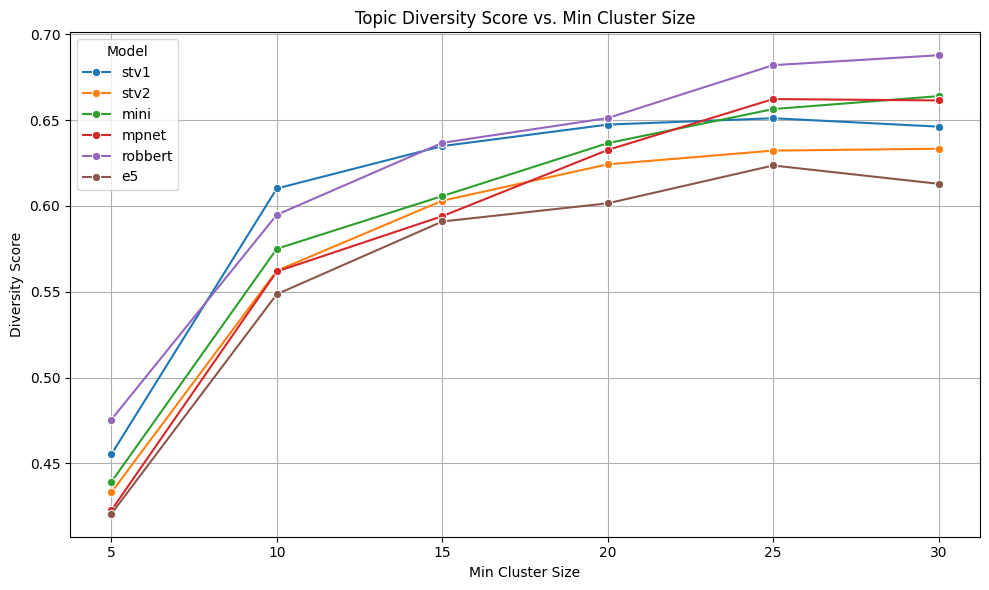

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Convert diversity_results into a DataFrame for easier plotting
data = []

for (name, size), metrics in diversity_results.items():
    data.append({
        "Model": name,
        "Min Cluster Size": size,
        "Diversity Score": metrics["diversity_score"]
    })

df = pd.DataFrame(data)

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Min Cluster Size", y="Diversity Score", hue="Model", marker="o")

plt.title("Topic Diversity Score vs. Min Cluster Size")
plt.xlabel("Min Cluster Size")
plt.ylabel("Diversity Score")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()


In [54]:
df.to_csv("/workspace/persistent/mijnidbcoachnlp/new_analysis/results/model_diversity_vs_min_cluster_size.csv")

#### 3.2.2. Diversity over n_components

In [18]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired

# Shared settings (avoid code duplication)
bertopic_settings = {
    "umap_model": UMAP(n_neighbors=15, n_components=7, min_dist=0.0, metric='cosine', random_state=42), # fixed random_state for reproducibility
    "hdbscan_model": HDBSCAN(min_cluster_size=25, metric='euclidean', cluster_selection_method='eom', prediction_data=False),
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": True
    #"representation_model": { 
    #    "KeyBERTInspired": KeyBERTInspired()
        #...
    #}
}

In [19]:
# model the diversity of different models over a range of parameters 
diversity_vs_n_components_results = defaultdict(dict)
topic_model = BERTopic(**bertopic_settings)

for name, embedding_model, embeddings in models_and_embeddings:
    

    # search over min_cluster_size
    for n_components in range_n_components:
        # configure the base settings
        topic_model.umap_model = UMAP(n_neighbors=15, n_components=n_components, min_dist=0.0, metric='cosine', random_state=42)

        print(f"Tuning model: {name} at n_components {n_components}")

        topics, probs = topic_model.fit_transform(sentences, embeddings)
        top_words = get_top_words(topic_model, top_n=10) 
        diversity_score = get_topic_diversity(top_words)
        print(f"The diversity score of model {name} at n_componnet {n_components} is {diversity_score}")
        diversity_vs_n_components_results[(name, n_components)]["n_component"] = n_components
        diversity_vs_n_components_results[(name, n_components)]["diversity_score"] = diversity_score

2025-05-26 18:57:13,244 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Tuning model: stv1 at n_components 5


2025-05-26 18:58:37,398 - BERTopic - Dimensionality - Completed ✓
2025-05-26 18:58:37,404 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 18:58:41,699 - BERTopic - Cluster - Completed ✓
2025-05-26 18:58:41,715 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 18:58:42,579 - BERTopic - Representation - Completed ✓
2025-05-26 18:58:43,413 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


The diversity score of model stv1 at n_componnet 5 is 0.6478723404255319
Tuning model: stv1 at n_components 6


2025-05-26 18:59:40,255 - BERTopic - Dimensionality - Completed ✓
2025-05-26 18:59:40,262 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 18:59:42,329 - BERTopic - Cluster - Completed ✓
2025-05-26 18:59:42,344 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 18:59:43,241 - BERTopic - Representation - Completed ✓
2025-05-26 18:59:44,235 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

The diversity score of model e5 at n_componnet 8 is 0.6005128205128205
Tuning model: e5 at n_components 9


2025-05-26 19:33:03,210 - BERTopic - Dimensionality - Completed ✓
2025-05-26 19:33:03,218 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 19:33:05,688 - BERTopic - Cluster - Completed ✓
2025-05-26 19:33:05,703 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 19:33:06,636 - BERTopic - Representation - Completed ✓
2025-05-26 19:33:07,438 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


The diversity score of model e5 at n_componnet 9 is 0.6125603864734299
Tuning model: e5 at n_components 10


2025-05-26 19:34:06,540 - BERTopic - Dimensionality - Completed ✓
2025-05-26 19:34:06,544 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 19:34:09,403 - BERTopic - Cluster - Completed ✓
2025-05-26 19:34:09,416 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 19:34:10,299 - BERTopic - Representation - Completed ✓


The diversity score of model e5 at n_componnet 10 is 0.6059113300492611


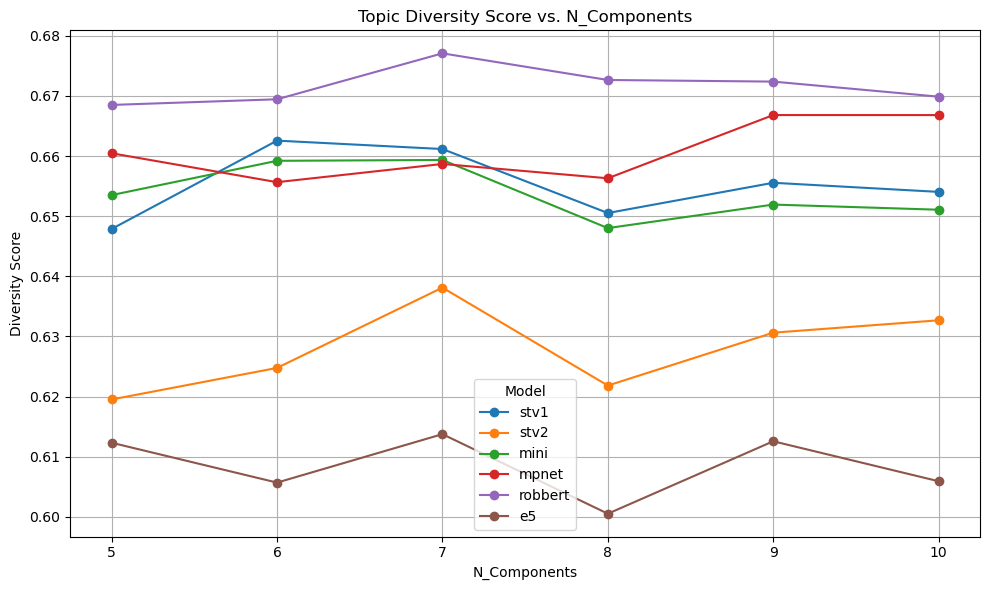

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert diversity_results into a DataFrame
data = []

for (name, n), metrics in diversity_vs_n_components_results.items():
    data.append({
        "Model": name,
        "N_Components": n,
        "Diversity Score": metrics["diversity_score"]
    })

df = pd.DataFrame(data)

# Get unique model names
models = df["Model"].unique()

# Plot
plt.figure(figsize=(10, 6))

for model in models:
    subset = df[df["Model"] == model]
    plt.plot(
        subset["N_Components"],
        subset["Diversity Score"],
        marker='o',
        label=model
    )

plt.title("Topic Diversity Score vs. N_Components")
plt.xlabel("N_Components")
plt.ylabel("Diversity Score")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
df.to_csv("/workspace/persistent/mijnidbcoachnlp/new_analysis/results/model_diversity_vs_n_components.csv")

#### 3.2.3. Observe trends of diversity over n_neighbors

In [20]:
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer
from bertopic.representation import KeyBERTInspired

# Shared settings (avoid code duplication)
bertopic_settings = {
    "umap_model": UMAP(n_neighbors=15, n_components=7, min_dist=0.0, metric='cosine', random_state=42), # fixed random_state for reproducibility
    "hdbscan_model": HDBSCAN(min_cluster_size=25, metric='euclidean', cluster_selection_method='eom', prediction_data=False),
    "vectorizer_model": CountVectorizer(stop_words=dutch_stopwords, min_df=2, ngram_range=(1, 1), token_pattern=r'\b[a-zA-Z]{3,}\b'),
    "calculate_probabilities": False,
    "verbose": True
    #"representation_model": { 
    #    "KeyBERTInspired": KeyBERTInspired()
        #...
    #}
}

In [21]:
# model the diversity of different models over a range of parameters 

diversity_vs_n_neighbors_results = defaultdict(dict)

for name, embedding_model, embeddings in models_and_embeddings:
    # configure the base settings
    topic_model = BERTopic(**bertopic_settings)

    # search over min_cluster_size
    for n_neighbors in range_n_neighbors:
        topic_model.umap_model = UMAP(n_neighbors=15, n_components=n_neighbors, min_dist=0.0, metric='cosine', random_state=42)

        print(f"Tuning model: {name} at n_neighbors {n_neighbors}")

        topics, probs = topic_model.fit_transform(sentences, embeddings)
        top_words = get_top_words(topic_model, top_n=10) 
        diversity_score = get_topic_diversity(top_words)
        print(f"The diversity score of model {name} at n_neighbors {n_neighbors} is {diversity_score}")
        diversity_vs_n_neighbors_results[(name, n_neighbors)]["n_neighbors"] = n_neighbors
        diversity_vs_n_neighbors_results[(name, n_neighbors)]["diversity_score"] = diversity_score

2025-05-26 23:24:40,879 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Tuning model: stv1 at n_neighbors 5


2025-05-26 23:25:59,468 - BERTopic - Dimensionality - Completed ✓
2025-05-26 23:25:59,472 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 23:26:04,080 - BERTopic - Cluster - Completed ✓
2025-05-26 23:26:04,097 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 23:26:05,083 - BERTopic - Representation - Completed ✓
2025-05-26 23:26:05,937 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


The diversity score of model stv1 at n_neighbors 5 is 0.6478723404255319
Tuning model: stv1 at n_neighbors 10


2025-05-26 23:27:05,154 - BERTopic - Dimensionality - Completed ✓
2025-05-26 23:27:05,158 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-26 23:27:07,737 - BERTopic - Cluster - Completed ✓
2025-05-26 23:27:07,752 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-26 23:27:08,648 - BERTopic - Representation - Completed ✓
2025-05-26 23:27:09,487 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


...

The diversity score of model e5 at n_neighbors 20 is 0.6247422680412371
Tuning model: e5 at n_neighbors 25


2025-05-27 00:09:12,106 - BERTopic - Dimensionality - Completed ✓
2025-05-27 00:09:12,113 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-27 00:09:18,445 - BERTopic - Cluster - Completed ✓
2025-05-27 00:09:18,462 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-27 00:09:19,445 - BERTopic - Representation - Completed ✓
2025-05-27 00:09:20,219 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


The diversity score of model e5 at n_neighbors 25 is 0.6128205128205129
Tuning model: e5 at n_neighbors 30


2025-05-27 00:10:48,715 - BERTopic - Dimensionality - Completed ✓
2025-05-27 00:10:48,726 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-27 00:10:54,623 - BERTopic - Cluster - Completed ✓
2025-05-27 00:10:54,639 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-05-27 00:10:55,573 - BERTopic - Representation - Completed ✓


The diversity score of model e5 at n_neighbors 30 is 0.6038043478260869


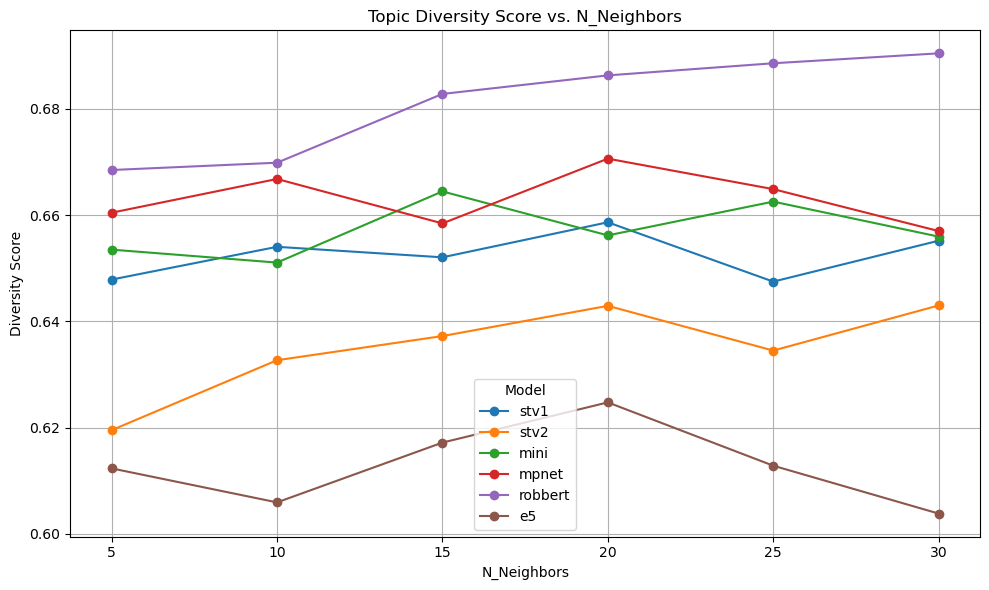

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert diversity_results into a DataFrame
data = []

for (name, n), metrics in diversity_vs_n_neighbors_results.items():
    data.append({
        "Model": name,
        "N_Neighbors": n,
        "Diversity Score": metrics["diversity_score"]
    })

df = pd.DataFrame(data)

# Get unique model names
models = df["Model"].unique()

# Plot
plt.figure(figsize=(10, 6))

for model in models:
    subset = df[df["Model"] == model]
    plt.plot(
        subset["N_Neighbors"],
        subset["Diversity Score"],
        marker='o',
        label=model
    )

plt.title("Topic Diversity Score vs. N_Neighbors")
plt.xlabel("N_Neighbors")
plt.ylabel("Diversity Score")
plt.legend(title="Model")
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
df.to_csv("/workspace/persistent/mijnidbcoachnlp/new_analysis/results/model_diversity_vs_n_neighbors.csv")

In [ ]:
from octis.evaluation_metrics.coherence_metrics import Coherence
from octis.evaluation_metrics.diversity_metrics import TopicDiversity

def get_top_words(topic_model, top_n: int) -> List[List[str]]:
    """Extract top words for each topic from BERTopic (excluding outliers)."""
    topics = topic_model.get_topics()  # topics is a dict: {topic_num: [(word, score), ...]}
    top_words = []
    for topic_num, word_score_list in topics.items():
        if topic_num == -1:
            continue  # Skip outlier topic (-1)
        words = [word for word, _ in word_score_list[:top_n]]  # Get only the top N words
        top_words.append(words)
    return top_words

def get_c_v(top_words, tokenized_texts, dictionary):
    """Calculate C_v coherence score using OCTIS."""
    # OCTIS Coherence metric requires texts as list of strings (space separated tokens)
    coherence_metric = Coherence(
        texts=tokenized_texts,
        topk=len(top_words[0]),  # Number of words per topic to consider
        measure='c_v'  # Options: 'c_v', 'c_npmi', 'c_uci', 'u_mass'
    )
    
    # OCTIS expects topics in format: [[word1, word2,...], [word1, word2,...], ...]
    score = coherence_metric.score({'topics': top_words})
    return score

def get_npmi(top_words, tokenized_texts, dictionary):
    """Calculate NPMI coherence using OCTIS."""
    # OCTIS Coherence metric requires texts as list of strings (space separated tokens)

    coherence_metric = Coherence(
        texts=tokenized_texts,
        topk=len(top_words[0]),  # Number of words per topic to consider
        measure='c_npmi'  # Using normalized pointwise mutual information
    )
    
    score = coherence_metric.score({'topics': top_words})
    return score

def get_u_mass(top_words, texts, tokenized_texts, dictionary):
    """Calculate u_mass coherence using OCTIS."""
    coherence_metric = Coherence(
        texts=tokenized_texts,
        topk=len(top_words[0]),
        measure='u_mass'  # Using u_mass coherence
    )
    
    score = coherence_metric.score({'topics': top_words})
    return score


def get_outlier_proportion(topic_model):
    """Calculate the percentage of documents labeled as outliers (topic=-1)."""
    topics = topic_model.topics_
    outlier_count = list(topics).count(-1)
    return outlier_count / len(topics)


def get_topic_diversity(top_words, topk=5):
    """
    Compute topic diversity using OCTIS's TopicDiversity metric.
    
    Args:
        top_words: List of lists, where each sublist contains top words for a topic 
                (e.g., [["word1", "word2"], ["word3", "word4"], ...]).
        topk: Number of top words to consider (must match the length of sublists in top_words).
    
    Returns:
        diversity_score: Float between 0 (low diversity) and 1 (high diversity).
    """
    metric = TopicDiversity(topk=topk)
    diversity_score = metric.score({"topics": top_words})  # OCTIS expects {"topics": ...}
    return diversity_score

def evaluate_model(topic_model, tokens, dictionary):
    results = {}
    top_words = get_top_words(topic_model, 10)
    # Coherence Scores
    if tokens is not None and dictionary is not None:
        npmi_score = (top_words, tokenized_texts, dictionary)
        c_v_score = (top_words, tokenized_texts, dictionary)
        results["c_v_coherence"] = c_v_score
        results['npmi_coherence'] = npmi_score
    else:
        results['c_v_coherence'] = None
        results['npmi_coherence'] = None
    
    # Outlier Proportion
    outlier_prop = get_outlier_proportion(topic_model)
    results['outlier_proportion'] = outlier_prop

    # Topic Diversity
    topic_diversity = get_topic_diversity(top_words)
    results['topic_diversity'] = topic_diversity

    # Top words
    
    print("\n--- Model Evaluation Metrics ---")
    for metric, value in results.items():
        print(f"{metric}: {value:.4f}" if isinstance(value, (int, float)) and value is not None else f"{metric}: {value}")
    for words in top_words[:5]:
        print(words)
    print("--------------------------------\n")

    return results
